# Docker Local Execution

## Docker Desktop Dashboard

If you have Docker Desktop on Mac or Windows, you will have the Dashboard application available. While you will see the dashboard for illustrations, majority of the work as an engineer will be through the command line. 

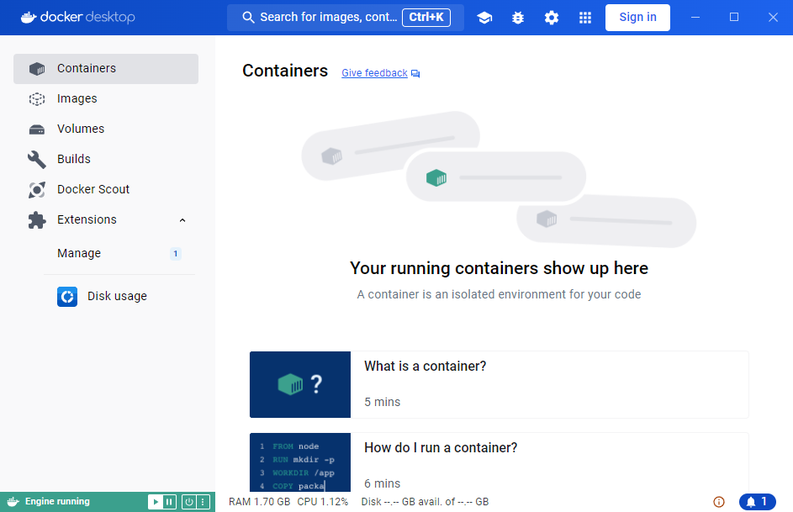

## Docker CLI

Docker CLI is the primary interface to interact with Docker. All commands start with `docker`. 

Try running `docker --help` to see the help text:

<details>
<summary>Docker Help output (truncated)</summary>

```bash

debian:~$ docker --help

Usage:  docker [OPTIONS] COMMAND

A self-sufficient runtime for containers

Common Commands:
  run         Create and run a new container from an image
  exec        Execute a command in a running container
  ps          List containers
  build       Build an image from a Dockerfile
  pull        Download an image from a registry
  push        Upload an image to a registry
  images      List images
  login       Log in to a registry
  logout      Log out from a registry
  search      Search Docker Hub for images
  version     Show the Docker version information
  info        Display system-wide information

...

Run 'docker COMMAND --help' for more information on a command.

For more help on how to use Docker, head to https://docs.docker.com/go/guides/
```

</details>


### Docker Container Processes

Initially, there will be no containers running. TO verify this we can check container statuses using:

```bash
docker ps
```

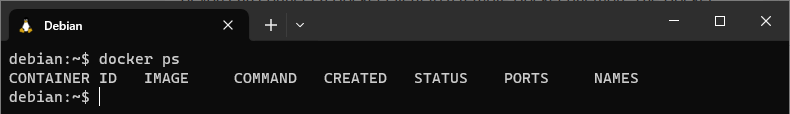

This will show all active containers that are started, running or paused. To see all containers including the stopped/exited containers, use the `-a` argument: 

```bash
docker ps -a
```

### Running a container

To run a container we need an image. For this example we can use the `hello-world` image. The command to run this is:

```bash
docker run [OPTIONS] IMAGE [COMMAND] [ARGS...]
```

So try executing the following command:

```bash
docker run hello-world:latest
```

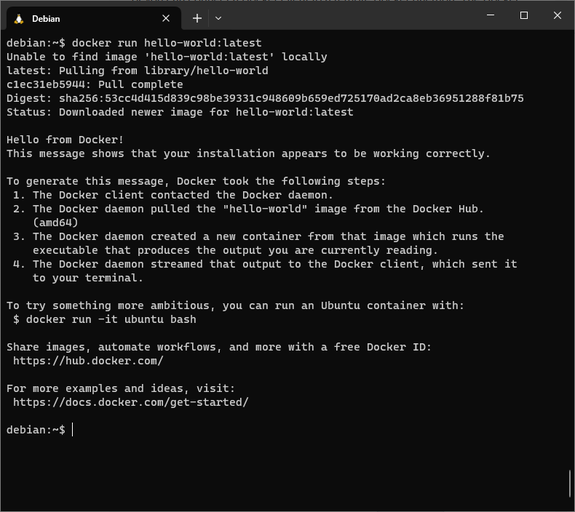

#### Docker Images

Let's look at docker images now. `image ls` sub-command can be used to list all the local docker images. Run the following:

```bash
docker image ls
```

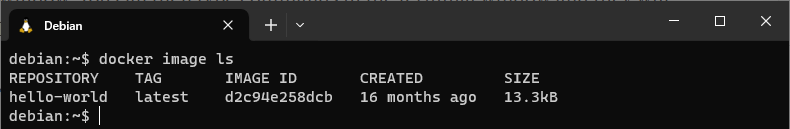

This shows the docker image repository information and shows the one `hello-world` image you used.

#### Docker Containers

Now we know the container started and stopped. so let's look at container details as before with `docker ps` and `docker ps -a`.

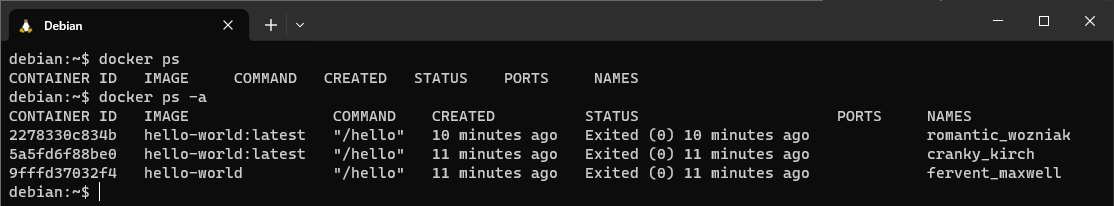

As you can see the first command doesn't return any containers. This is expected as our container finished its program and exited. This exited status is shown when using `-a` (all) argument. I tried this a few times so it shows 3 entries. 

You can see the image name used for executing the container, a random container ID and name, the command the container executed and created time.



#### What's happens with `docker run`?

**Image Name**

Firstly, the image we try to execute is `hello-world:latest`. There are two parts to this we must understand. The image name is `hello-world` and the version tag is `latest`. 

Image name has the following full format: `[HOST[:PORT_NUMBER]/]PATH[:TAG]`.

- Host: This is the registry hostname. By default refers to Docker Hub (`docker.io`)
- Port number: The port number for the registry host. Default is 443 (using https)
- Path: this is the full path of the image. Registry will have namespaces and image names separated by `/`. Example: `apache/airflow`. The default namespace for DockerHub is `library`. So hello world image is actually `library/hello-world`
- Tag: This is the tag for the image, representing a version or another label. the default tag is `latest`.

Knowing this we can fully define the hello world image name to be `docker.io/library/hello-world:latest`

If you execute `docker run` with this fully qualified name the result should be similar:

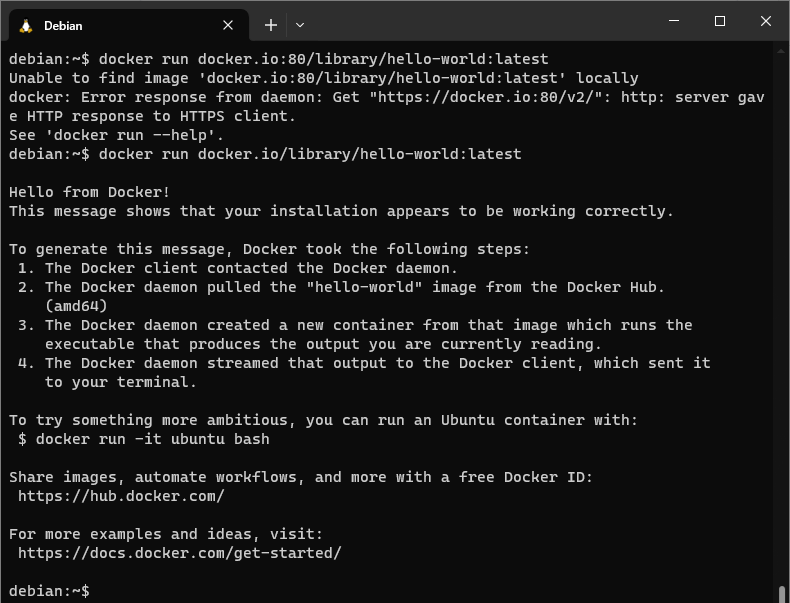

**Image Pull**

The first action `docker run` performs is to check whether the requested image is available locally. The first time we run docker image it will not find it and has to download it from the remote docker registry. Thus you see:

```bash
# Doesn't find the image locally
Unable to find image 'hello-world:latest' locally

# Pulls the image from registry (default library namespace)
latest: Pulling from library/hello-world

# Pulls the image *layer*
c1ec31eb5944: Pull complete
Digest: sha256:53cc4d415d839c98be39331c948609b659ed725170ad2ca8eb36951288f81b75
Status: Downloaded newer image for hello-world:latest
```

To pull an image without executing it run `docker pull <image>`. eg. `docker pull hello-world:latest`. This will download the image without any further action.

**Container Create**

The next action is to create the container. This can be manually done by running the `docker create` command. 

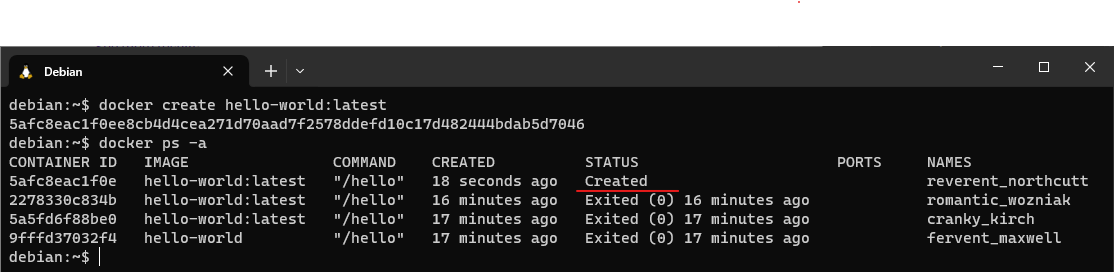

Here you can see that the container is in created state. The container ID in the `ps` command output is truncated to the first 12 characters.

**Container Start**

The next and final action is to start running the container which can be manually performed by `docker start` command as follow:

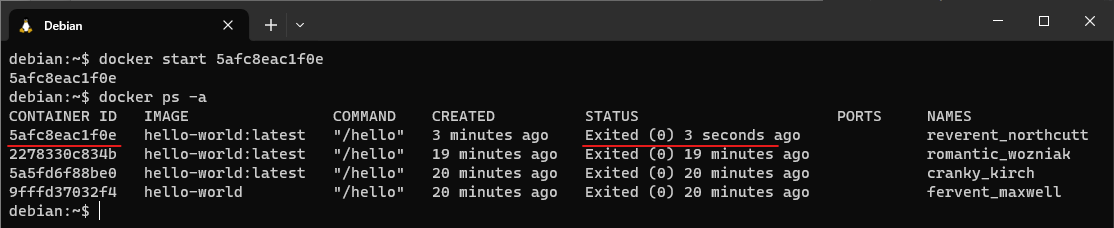

Here the start command simply returns the container ID that was started, no output from the container is shown. `docker ps -a` now shows that container as `Exited` status similar to previous containers.

To connect your terminal to the containers to view the console output (stdout/stderr) you can add the `-a/--attach` argument as follows:

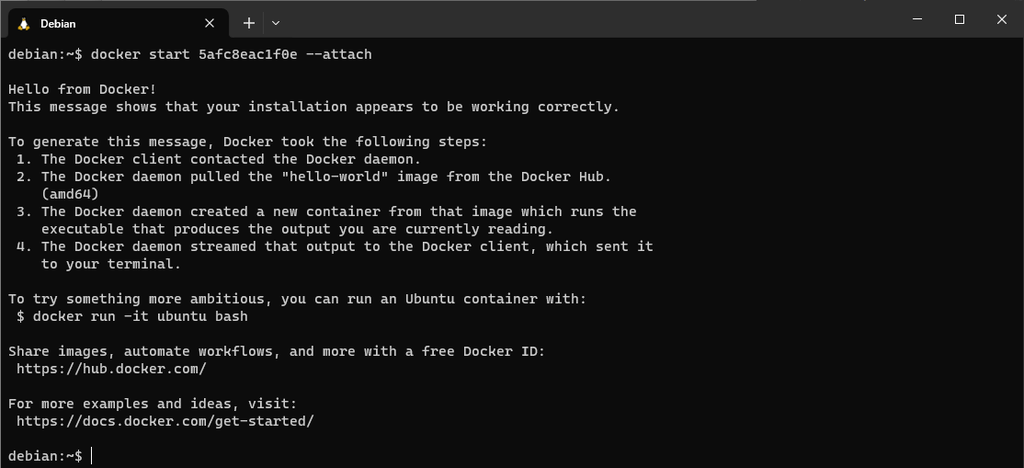


### Reuse containers

Any stopped container can be restarted and reused by running `docker start` command. 

### Cleaning up containers

As you can see stopped containers can build up over time. There are three ways to clean up:

1. Use `docker run --rm`. the `--rm` option will delete the created container once it has exited. 
1. Use `docker container rm <container id>` command to delete a stopped container
1. Use `docker system prune` command to clean up unused containers, images, networks and disk.Images, containers and volumes take up the disk space so cleaning regularly is a good hygiene practice.

Try them in order and see the effect by comparing the output of `docker ps -a` after each command.
